In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(
    'Public-Machine-Readable-school-leavers-2014-2024.txt',
    encoding='utf-16',
    sep='\t'
)

print(df.shape)
print(df.columns.tolist())
df.head()

/var/folders/5x/cx4dbrdd2jj105gn86s5pyyh0000gn/T/ipykernel_33518/3877803402.py:6: DtypeWarning: Columns (0: School: Equity Index Band, 1: School: Equity Index Group) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


(360615, 28)
['Year: Left School', 'Student: Ethnic Group', 'Student: Student Gender', 'Student: Leaving Year Level', 'Student: Student Age', 'Student: Age (Retention To 17)', 'Qualification: Highest Attainment (5 groups)', 'Qualification: Level 1 or Above', 'Qualification: Level 2 or Above', 'Qualification: Level 3 or UE Award', 'School: School Type', 'School: School Sector', 'School: Authority', 'School: Equity Index Band', 'School: Equity Index Group', 'School: Definition', 'Affiliation', 'School: School Gender', 'Region: General Electorate', 'Region: Māori Electorate', 'Region: Territorial Local Authority Ward', 'Region: TA Board', 'Region: Education Area', 'Region: Regional Council', 'School: Decile', 'School: Quintile', 'Region: Territorial Authority', 'Students (∑ Values)']


,Year: Left School,Student: Ethnic Group,Student: Student Gender,Student: Leaving Year Level,Student: Student Age,Student: Age (Retention To 17),Qualification: Highest Attainment (5 groups),Qualification: Level 1 or Above,Qualification: Level 2 or Above,Qualification: Level 3 or UE Award,...,Region: General Electorate,Region: Māori Electorate,Region: Territorial Local Authority Ward,Region: TA Board,Region: Education Area,Region: Regional Council,School: Decile,School: Quintile,Region: Territorial Authority,Students (∑ Values)
0,2014,Māori,Female,Other/Unknown,Age 16,Left before 17th birthday,Below Level 1 Qualification,Below NCEA Level 1,Below NCEA Level 2,Below Level 3 (Without UE),...,East Coast,Ikaroa-Rāwhiti,Gisborne District,Gisborne District,"Hawke's Bay, Tairāwhiti",Gisborne Region,Decile 01,Quintile 1,Gisborne District,1
1,2014,Māori,Female,Other/Unknown,Age 17,Stayed until age 17 or above,Below Level 1 Qualification,Below NCEA Level 1,Below NCEA Level 2,Below Level 3 (Without UE),...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,2
2,2014,Māori,Female,Other/Unknown,Age 17,Stayed until age 17 or above,Level 1 Qualification,NCEA Level 1 or above,Below NCEA Level 2,Below Level 3 (Without UE),...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,1
3,2014,Māori,Female,Other/Unknown,Age 17,Stayed until age 17 or above,Level 1 Qualification,NCEA Level 1 or above,Below NCEA Level 2,Below Level 3 (Without UE),...,Hamilton West,Hauraki-Waikato,Hamilton City,Hamilton City,Waikato,Waikato Region,Decile 01,Quintile 1,Hamilton City,1
4,2014,Māori,Female,Other/Unknown,Age 17,Stayed until age 17 or above,Level 2 Qualification,NCEA Level 1 or above,NCEA Level 2 or above,Below Level 3 (Without UE),...,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,1


In [2]:
# Basic exploration
print("Year range:", df['Year: Left School'].unique())
print("\nEthnic groups:", df['Student: Ethnic Group'].unique())
print("\nRegions:", df['Region: Education Area'].unique())
print("\nLevel 2 values:", df['Qualification: Level 2 or Above'].unique())

Year range: [2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]

Ethnic groups: <ArrowStringArray>
['Māori', 'Pacific', 'Asian', 'MELAA', 'Other', 'European/Pākehā',
 'All Leavers']
Length: 7, dtype: str

Regions: <ArrowStringArray>
[        'Hawke's Bay, Tairāwhiti',                  'Not Applicable',
                         'Waikato',         'Bay of Plenty, Waiariki',
                     'Tai Tokerau',             'Tāmaki Herenga Waka',
          'Tāmaki Herenga Tāngata',           'Tāmaki Herenga Manawa',
                'Otago, Southland',   'Taranaki, Whanganui, Manawatū',
                      'Wellington',     'Canterbury, Chatham Islands',
 'Nelson, Marlborough, West Coast']
Length: 13, dtype: str

Level 2 values: <ArrowStringArray>
['Below NCEA Level 2', 'NCEA Level 2 or above']
Length: 2, dtype: str


In [3]:
# Filter to All Leavers only, remove Not Applicable region
df_clean = df[
    (df['Student: Ethnic Group'] == 'All Leavers') &
    (df['Region: Education Area'] != 'Not Applicable')
].copy()

# Calculate Level 2 achievement rate by year and region
level2 = df_clean.groupby(
    ['Year: Left School', 'Region: Education Area', 'Qualification: Level 2 or Above']
)['Students (∑ Values)'].sum().reset_index()

# Pivot to get achievement rate
level2_pivot = level2.pivot_table(
    index=['Year: Left School', 'Region: Education Area'],
    columns='Qualification: Level 2 or Above',
    values='Students (∑ Values)',
    fill_value=0
).reset_index()

level2_pivot['Achievement Rate'] = (
    level2_pivot['NCEA Level 2 or above'] /
    (level2_pivot['NCEA Level 2 or above'] + level2_pivot['Below NCEA Level 2'])
) * 100

print(level2_pivot.head(10))

Qualification: Level 2 or Above  Year: Left School  \
0                                             2014   
1                                             2014   
2                                             2014   
3                                             2014   
4                                             2014   
5                                             2014   
6                                             2014   
7                                             2014   
8                                             2014   
9                                             2014   

Qualification: Level 2 or Above           Region: Education Area  \
0                                        Bay of Plenty, Waiariki   
1                                    Canterbury, Chatham Islands   
2                                        Hawke's Bay, Tairāwhiti   
3                                Nelson, Marlborough, West Coast   
4                                               Otago, Southland 

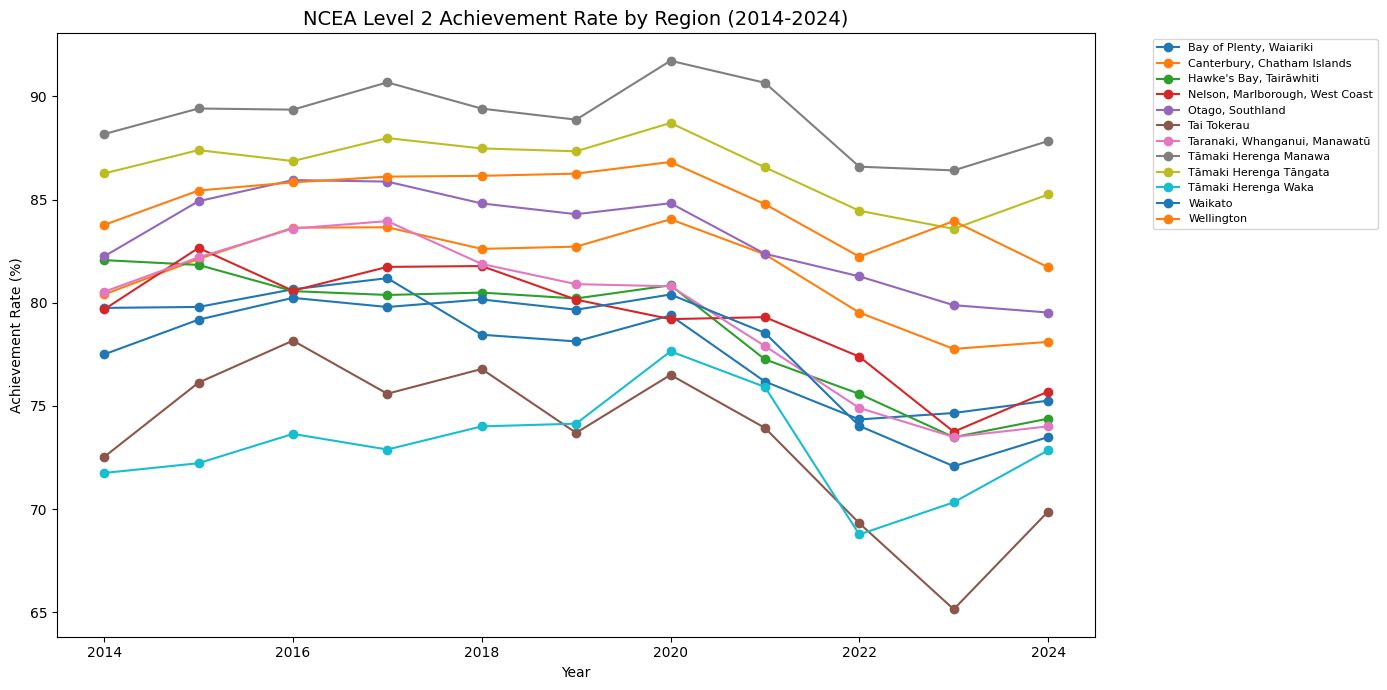

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Line plot: Achievement rate by region over time
plt.figure(figsize=(14, 7))

regions = level2_pivot['Region: Education Area'].unique()

for region in regions:
    data = level2_pivot[level2_pivot['Region: Education Area'] == region]
    plt.plot(data['Year: Left School'], data['Achievement Rate'], marker='o', label=region)

plt.title('NCEA Level 2 Achievement Rate by Region (2014-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Achievement Rate (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('ncea_level2_by_region.png', dpi=150)
plt.show()